In [2]:
from datasets import load_dataset

dataset = load_dataset("unsloth/LaTeX_OCR")

dataset

c:\Users\Public\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sumer Singh\.cache\huggingface\hub\datasets--unsloth--LaTeX_OCR. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 7632/7632 [00:00<00:00, 65551.43 examples/s]


DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 68686
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 7632
    })
})

In [19]:
sample = dataset["train"][10]
sample

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x40>,
 'text': '[ [ B _ { n } ^ { + } , b _ { 2 } ^ { - } ] , b _ { 2 } ^ { + } ] = n B _ { n } ^ { + } , \\quad [ [ B _ { n } ^ { - } , b _ { 2 } ^ { + } ] , b _ { 2 } ^ { - } ] = n B _ { n } ^ { - } .'}

(np.float64(-0.5), np.float64(319.5), np.float64(39.5), np.float64(-0.5))

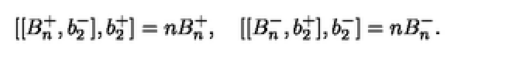

In [20]:
import matplotlib.pyplot as plt

plt.imshow(sample["image"])
plt.axis("off")

In [21]:
print(sample["text"])

[ [ B _ { n } ^ { + } , b _ { 2 } ^ { - } ] , b _ { 2 } ^ { + } ] = n B _ { n } ^ { + } , \quad [ [ B _ { n } ^ { - } , b _ { 2 } ^ { + } ] , b _ { 2 } ^ { - } ] = n B _ { n } ^ { - } .


In [24]:
sizes = []

for i in range(10000):
    sample = dataset["train"][i]
    sizes.append(sample["image"].size)

sizes[100:110]

[(200, 50),
 (240, 40),
 (240, 40),
 (240, 40),
 (360, 50),
 (360, 40),
 (200, 40),
 (280, 40),
 (400, 50),
 (160, 40)]

In [25]:
import numpy as np

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f"Average Width: {np.mean(widths)}")
print(f"Average Height: {np.mean(heights)}")
print(f"Max Width: {np.max(widths)}")
print(f"Max Height: {np.max(heights)}")

Average Width: 249.706
Average Height: 47.131
Max Width: 500
Max Height: 160


In [34]:
lengths = []
for i in range(10000):
    lengths.append(len(dataset["train"][i]["text"]))

print(f"Average Length: {np.mean(lengths)}")
print(f"Max Length: {np.max(lengths)}")

Average Length: 148.3156
Max Length: 595


In [ ]:
def estimate_tokens(img):
    w, h = img.size
    return (w // 28) * (h // 28)

tokens = [estimate_tokens(dataset["train"][i]["image"]) for i in range(1000)]

print(f"Average Tokens: {np.mean(tokens)}")
print(f"Max Tokens: {np.max(tokens)}")  

AttributeError: 'generator' object has no attribute 'size'